In [1]:
import pandas as pd 
import numpy as np 

In [2]:
df = pd.read_csv('../data/heart_disease.csv')

In [3]:
df.head()

,Age,Gender,Cholesterol,Blood Pressure,Heart Rate,Smoking,Alcohol Intake,Exercise Hours,Family History,Diabetes,Obesity,Stress Level,Blood Sugar,Exercise Induced Angina,Chest Pain Type,Heart Disease
0,75,Female,228,119,66,Current,Heavy,1,No,No,Yes,8,119,Yes,Atypical Angina,1
1,48,Male,204,165,62,Current,NaN,5,No,No,No,9,70,Yes,Typical Angina,0
2,53,Male,234,91,67,Never,Heavy,3,Yes,No,Yes,5,196,Yes,Atypical Angina,1
3,69,Female,192,90,72,Current,NaN,4,No,Yes,No,7,107,Yes,Non-anginal Pain,0
4,62,Female,172,163,93,Never,NaN,6,No,Yes,No,2,183,Yes,Asymptomatic,0


In [5]:
X = df.drop('Heart Disease',axis=1)
y = df['Heart Disease']

print(X)
print(y)

     Age  Gender  Cholesterol  Blood Pressure  Heart Rate  Smoking  \
0     75  Female          228             119          66  Current   
1     48    Male          204             165          62  Current   
2     53    Male          234              91          67    Never   
3     69  Female          192              90          72  Current   
4     62  Female          172             163          93    Never   
..   ...     ...          ...             ...         ...      ...   
995   56  Female          269             111          86    Never   
996   78  Female          334             145          76    Never   
997   79    Male          151             179          81    Never   
998   60  Female          326             151          68   Former   
999   53    Male          226             116          82  Current   

    Alcohol Intake  Exercise Hours Family History Diabetes Obesity  \
0            Heavy               1             No       No     Yes   
1              NaN 

In [7]:
numerical_features = X.select_dtypes(include = ["float64","int64"]).columns
categorical_features = X.select_dtypes(include = "str").columns

print(numerical_features)
print(categorical_features)

Index(['Age', 'Cholesterol', 'Blood Pressure', 'Heart Rate', 'Exercise Hours',
       'Stress Level', 'Blood Sugar'],
      dtype='str')
Index(['Gender', 'Smoking', 'Alcohol Intake', 'Family History', 'Diabetes',
       'Obesity', 'Exercise Induced Angina', 'Chest Pain Type'],
      dtype='str')


In [8]:
from sklearn.model_selection import train_test_split 
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    stratify=y,
    random_state=42,
    test_size=0.20
)

In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder,StandardScaler

preprocessor = ColumnTransformer(
    transformers = [
        (
            "num",
            Pipeline(
                [
                    ("imputer",SimpleImputer(strategy="median")),
                    ("scaler",StandardScaler())
                ]
            ),
            numerical_features
        ),
         (
            "cat",
            Pipeline(
                [
                    ("imputer",SimpleImputer(strategy="most_frequent")),
                    ("scaler",OneHotEncoder(handle_unknown="ignore"))
                ]
            ),
            categorical_features
        )
        
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [11]:
from sklearn.svm import SVC

model = SVC(
    kernel="linear"
)

model.fit(X_train_processed,y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [12]:
y_pred = model.predict(X_test_processed)

In [14]:
from sklearn.metrics import (
accuracy_score,
precision_score,
recall_score,
f1_score,
confusion_matrix,
ConfusionMatrixDisplay,
classification_report
)

print("accuracy:",accuracy_score(y_test,y_pred))
print("precision:",precision_score(y_test,y_pred))
print("recall:",recall_score(y_test,y_pred))
print("f1:",f1_score(y_test,y_pred))
print("Classification report:",classification_report(y_test,y_pred))

accuracy: 0.865
precision: 0.8591549295774648
recall: 0.782051282051282
f1: 0.8187919463087249
Classification report:               precision    recall  f1-score   support

           0       0.87      0.92      0.89       122
           1       0.86      0.78      0.82        78

    accuracy                           0.86       200
   macro avg       0.86      0.85      0.86       200
weighted avg       0.86      0.86      0.86       200



In [15]:
kernels = ["linear","poly","rbf","sigmoid"]
accuracies = []
precisions = []
recalls = []
f1s = []

for kernel in kernels:
    test_model = SVC(
        kernel = kernel
    )

    test_model.fit(X_train_processed,y_train)

    test_model_preds = test_model.predict(X_test_processed)

    accuracies.append(accuracy_score(y_test,test_model_preds))

    precisions.append(precision_score(y_test,test_model_preds))

    recalls.append(recall_score(y_test,test_model_preds))

    f1s.append(f1_score(y_test,test_model_preds))

In [16]:
test_model_results = pd.DataFrame(
    {
        "kernels_type":kernels,
        "accuracy":accuracies,
        "precision":precisions,
        "recall":recalls,
        "f1_score":f1s
    }
)

test_model_results.head(4)

,kernels_type,accuracy,precision,recall,f1_score
0,linear,0.865,0.859155,0.782051,0.818792
1,poly,0.945,0.958904,0.897436,0.927152
2,rbf,0.905,0.893333,0.858974,0.875817
3,sigmoid,0.820,0.800000,0.717949,0.756757


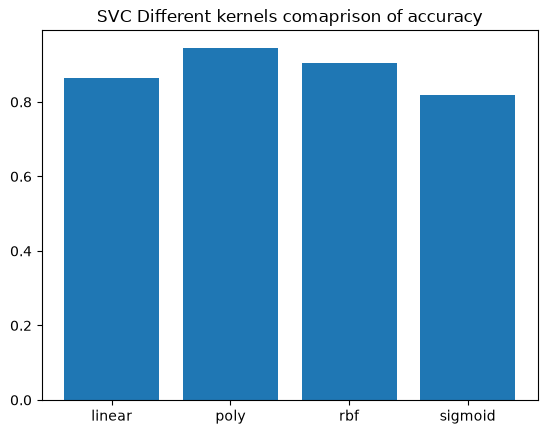

In [18]:
import matplotlib.pyplot as plt

plt.bar(
    test_model_results["kernels_type"],
    test_model_results["accuracy"]
)
plt.title("SVC Different kernels comaprison of accuracy")
plt.show()